# Set Up

En este notebook se compara contra la epoca 15, y se toma como referencia los valores del famfold que yo mismo obtuve

In [18]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# plt.rc("text", usetex=True)
# plt.rc("font", family="serif")

In [19]:
experiments = [
    "hc_100",
    "hc_200",
    "hc_400",
    "rnadist_100",
    "rnadist_200",
    "rnadist_400",
    "samples_100",
    "samples_200",
    "samples_400",
]

# sincFold 15


In [20]:
def get_data(PATH):
    df = pd.read_csv(PATH, index_col=0)
    df.reset_index(inplace=True)
    df.rename(columns={"index": "fam"}, inplace=True)
    df_ref = df[["fam", "famfold"]]
    df_ref.sort_values(by="fam", ascending=False, inplace=True)
    df.drop(columns=["famfold"], inplace=True)
    return df, df_ref


PATH = "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/sincFold/SILVER/train_and_spy/last_epoch/sincFold_testnspy_15_epochs.csv"
df, df_ref = get_data(PATH)

display(df)
display(df_ref)

/tmp/ipykernel_3304206/1682093681.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ref.sort_values(by="fam", ascending=False, inplace=True)


,fam,rnadist_100,rnadist_200,rnadist_400,hc_100,hc_200,hc_400,samples_100,samples_200,samples_400
0,23s,0.384,0.330,0.283,0.335,0.382,0.293,0.323,0.290,0.351
1,telomerase,0.192,0.169,0.134,0.198,0.143,0.094,0.155,0.141,0.164
2,16s,0.278,0.291,0.342,0.287,0.234,0.329,0.357,0.267,0.319
3,5s,0.362,0.437,0.365,0.429,0.449,0.382,0.448,0.255,0.438
4,grp1,0.347,0.348,0.348,0.341,0.298,0.340,0.310,0.345,0.311
5,srp,0.289,0.265,0.224,0.287,0.252,0.201,0.290,0.240,0.154
6,RNaseP,0.395,0.346,0.382,0.381,0.392,0.427,0.386,0.362,0.401
7,tmRNA,0.296,0.290,0.331,0.281,0.287,0.324,0.312,0.301,0.329
8,tRNA,0.652,0.629,0.606,0.615,0.616,0.655,0.568,0.630,0.603


,fam,famfold
7,tmRNA,0.302
1,telomerase,0.135
8,tRNA,0.562
5,srp,0.161
4,grp1,0.351
6,RNaseP,0.358
3,5s,0.360
0,23s,0.232
2,16s,0.305


In [21]:
df_ref.set_index("fam")["famfold"].to_dict()

{'tmRNA': 0.302,
 'telomerase': 0.135,
 'tRNA': 0.562,
 'srp': 0.161,
 'grp1': 0.351,
 'RNaseP': 0.358,
 '5s': 0.36,
 '23s': 0.232,
 '16s': 0.305}

In [22]:
def normalizar_y_melt(df, rna_llm, experiments):
    rna_llm_series = pd.Series(rna_llm.set_index("fam")["famfold"].to_dict())
    df_norm = df.copy()
    cols_to_normalize = [col for col in df.columns if col != "fam"]

    # Normalizar cada columna (vectorizado)
    df_norm[cols_to_normalize] = df_norm[cols_to_normalize].div(
        df_norm["fam"].map(rna_llm_series), axis=0
    )

    # Transformar a formato long
    dfn = df_norm.melt(
        id_vars="fam",
        value_vars=experiments,
        var_name="modelo",
        value_name="f1",
    )

    return dfn


def add_metodo_umbral(df: pd.DataFrame) -> pd.DataFrame:
    """Desglosa 'modelo' → ['metodo', 'umbral'] (string)."""
    out = df.copy()
    out[["metodo", "umbral"]] = out["modelo"].str.extract(r"([A-Za-z]+)_(\d+)")
    out["umbral"] = out["umbral"].astype(str)
    return out


# Transformar a formato long
dfl = df.melt(
    id_vars="fam",
    value_vars=experiments,
    var_name="modelo",
    value_name="f1",
)
dfn = normalizar_y_melt(df, df_ref, experiments)

In [23]:
s = dfn.groupby("modelo")["f1"].mean().sort_values().reset_index()
s = s.rename(columns={"f1": "rel_f1"})

s.to_csv(
    "/home/gkulemeyer/Documents/Repos/RNA-analysis/Experiments/f_ArchiveII/sincFold/SILVER/train_and_spy/last_epoch/sincFold_relf1.csv"
)
s

,modelo,rel_f1
0,samples_200,1.053404
1,hc_400,1.083022
2,rnadist_400,1.107971
3,samples_400,1.123927
4,hc_200,1.141762
5,rnadist_200,1.169515
6,samples_100,1.195751
7,hc_100,1.209602
8,rnadist_100,1.224632


In [24]:
PALETTE = {"100": "#1B9E77", "200": "#D95F02", "400": "#7570B3"}
MARKERS = {"hc": "*", "samples": "o", "rnadist": "^"}


dfl = add_metodo_umbral(dfl)  # absolutos
dfn = add_metodo_umbral(dfn)  # normalizados


# plot utils
def strip(ax, df, fam_map, seed=0):
    """Scatter categórico con jitter: color=umbral, marker=método."""
    # jitter
    rng = np.random.default_rng(seed)
    x = df["fam"].map(fam_map) + rng.uniform(-0.25, 0.25, len(df["fam"]))
    # plot
    for metodo, g in df.groupby("metodo"):
        ax.scatter(
            x[g.index],
            g["f1"],
            marker=MARKERS.get(metodo, "o"),
            c=[PALETTE[u] for u in g["umbral"]],
            edgecolors="k",
            lw=0.5,
            s=60,
            alpha=0.75,
            label=metodo,
        )


def combined_legend(fig, axes):
    """Leyenda única (métodos + umbrales) sin duplicados."""
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles += h
        labels += l
        if ax.get_legend():
            ax.get_legend().remove()

    color_handles = [
        Line2D([0], [0], marker="D", ls="", color=PALETTE[u], label=u) for u in PALETTE
    ]
    handles += color_handles
    labels += [h.get_label() for h in color_handles]

    uniq = dict(zip(labels, handles))
    fig.legend(uniq.values(), uniq.keys(), loc="lower center", ncol=5, frameon=False)

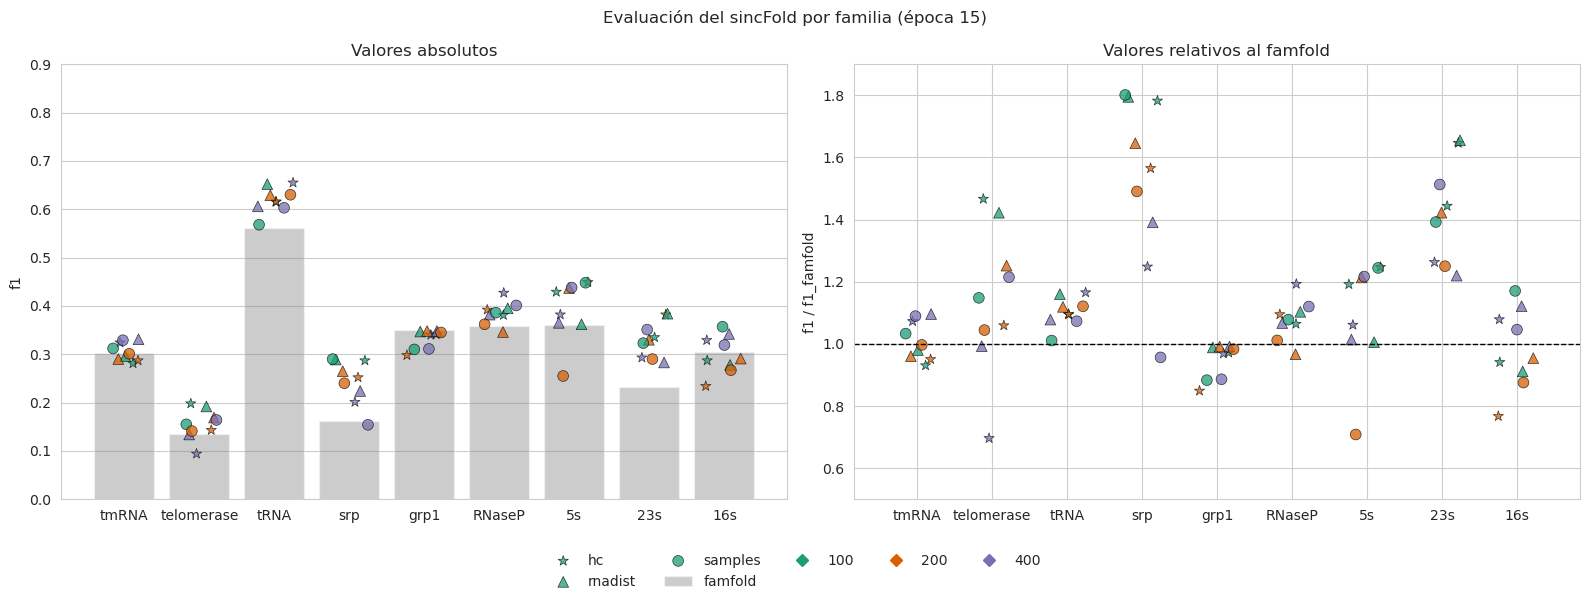

In [25]:
fam_order = sorted(dfl["fam"].unique(), reverse=True)
fam_map = {f: i for i, f in enumerate(fam_order)}

# ────────────── PLOT ──────────────
sns.set_style("whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# Panel A: valores absolutos
sns.barplot(
    data=df_ref,
    x="fam",
    y="famfold",
    color="gray",
    alpha=0.4,
    errorbar=None,
    ax=axes[0],
    label="famfold",
)
strip(axes[0], dfl, fam_map)
axes[0].set_ylim(0, 0.9)
axes[0].set_title("Valores absolutos")
axes[0].set_ylabel("f1")

# Panel B: valores relativos
strip(axes[1], dfn, fam_map)
axes[1].axhline(1, ls="--", lw=1, color="k")
axes[1].set_ylim(0.5, 1.9)
axes[1].set_title("Valores relativos al famfold")
axes[1].set_ylabel("f1 / f1_famfold")

# Etiquetas comunes
for ax in axes:
    ax.set_xlabel("")
    ax.set_xticks(range(len(fam_order)))
    ax.set_xticklabels(fam_order)

fig.suptitle("Evaluación del sincFold por familia (época 15)")
combined_legend(fig, axes)

plt.tight_layout(rect=[0, 0.1, 1, 1])
plt.show()